# Membuat Graph & Rank Kalimat

In [1]:
# import Library
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

import networkx as nx
import matplotlib.pyplot as plt
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from nltk.corpus import stopwords
from collections import Counter

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Import Csv

In [2]:
df = pd.read_csv('Final_Data.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Final_Data.csv'

## Cleaning Data

In [4]:
def preptext(text):
    text = re.sub(r'\s+', ' ', text) #menghapus extra spasi
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) #menghapus non-ascii characters
    text = re.sub(r"[^a-zA-Z :\.]", "", text) # Menghapus tanda baca
    text = re.sub(r'\d', ' ', text) # Menghapus angka
    text = text.encode('ascii','ignore').decode('utf-8') #Menghapus ASCII dan unicode
    text = text.replace('\n',' ') #Menghapus baris baru
    text = text.strip() #menghapus karakter kosong diawal dan akhir
    text = text.lower()
    
    # Tokenisasi
    words = word_tokenize(text)

    list_stopwords = set(stopwords.words("indonesian"))
    words = [word for word in words if word.lower() not in list_stopwords]
    return ' '.join(words)

df['isi_baru'] = df['Isi Berita'].apply(preptext)
print(df['isi_baru'].head())

0    beirut hizbullah lebanon mengumumkan pejuang p...
1    jakarta kejaksaan kejati jawa timur menangkap ...
2    jakarta menteri pertanian mentan andi amran su...
3    jakarta mantan menteri perdagangan mendag thom...
4    jakarta gerakan mahasiswa nasional indonesia g...
Name: isi_baru, dtype: object


In [5]:
kalimat = nltk.sent_tokenize(df['isi_baru'][15])
kalimat = [sentence.replace('.','') for sentence in kalimat]
kata = nltk.word_tokenize(df['isi_baru'][15])
kata = list(set(key for key in kata if key != '.'))

kalimat

['jakarta mantan menteri perdagangan thomas trikasih lembong tom lembong langsung ditahan kejaksaan agung kejagung ditetapkan tersangka dugaan korupsi kegiatan importasi gula kementerian perdagangan ',
 'mantan cocaptain tim nasional pemenangan anies baswedanmuhaimin iskandar tim amin mengenakan rompi tahanan kejagungrompi warna merah muda bertuliskan tahanan tindak pidana korupsi kejaksaan agung ri ',
 'tom kejagung menetapkan direktur pengembangan bisnis pt perusahaan perdagangan indonesia ppi cs tersangka penahananpenetapan tersangka direktur penyidik jampidsus kejagung ri abdul qohar kejagung jakarta selasa malam ',
 'pantauan lokasi tersangka cs nomor kondisi tangan terborgol ',
 'baca profil tom lembong mantan anak buah jokowi tim sukses anies disusul thomas lembong nomor menebar senyum awak media sepatah ',
 'digelandang mobil tahanan kejagungsebelumnya tim penyidik jaksa agung muda tindak pidana khusus jampidsus kejagung menetapkan thom lembong cs tersangka ',
 'langsung direkt

# Membuat Graph & Rank Kalimat

Kita akan membuat sebuah diagram (atau graph) untuk menunjukkan seberapa mirip kalimat-kalimat dalam sebuah berita. Tingkat kemiripan ini akan dihitung menggunakan cosine similarity. Agar diagramnya tidak terlalu rumit, kita hanya akan menghubungkan kalimat-kalimat yang memiliki kemiripan di atas 0.

### Menghitung TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) adalah teknik yang digunakan dalam pemrosesan teks untuk menilai pentingnya suatu kata dalam suatu dokumen relatif terhadap kumpulan dokumen (corpus).

Konsep ini terdiri dari dua bagian:


1.   Term Frequency (TF): Mengukur seberapa sering sebuah kata muncul dalam sebuah dokumen.
2.   Inverse Document Frequency (IDF): Mengukur seberapa jarang kata tersebut muncul dalam kumpulan dokumen (corpus).



Term Frequency (TF):

$$
\text{TF}(t, d) = \frac{\text{Jumlah kemunculan t dalam d}}{\text{Total jumlah kata dalam d}}
$$
Arti dari rumus ini:

1. TF(t, d): Menunjukkan frekuensi kata t dalam dokumen d.
2. Jumlah kemunculan t dalam d: Merupakan jumlah kali kata t muncul di dalam dokumen d.
3. Total jumlah kata dalam d: Merupakan total semua kata yang terdapat dalam dokumen d.


Inverse Document Frequency (IDF):

$$
\text{IDF}(t, D) = \log \left( \frac{N}{|\{d \in D : t \in d\}|} \right)
$$



TF-IDF:

$$
\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)
$$
TF-IDF(t, d, D):
1. Menunjukkan nilai TF-IDF untuk kata t dalam dokumen d dari kumpulan dokumen D. Ini adalah nilai yang mengindikasikan pentingnya kata tersebut dalam konteks dokumen dan corpus.
2. TF(t, d):Nilai Term Frequency untuk kata t dalam dokumen d. Ini mengukur seberapa sering kata t muncul dalam dokumen d. Semakin tinggi nilai TF, semakin sering kata tersebut muncul dalam dokumen, yang menunjukkan relevansinya.
3. IDF(t, D):Nilai Inverse Document Frequency untuk kata t dalam kumpulan dokumen D. Ini mengukur seberapa jarang kata tersebut muncul di seluruh corpus. Semakin jarang kata t muncul, semakin tinggi nilai IDF, yang menunjukkan bahwa kata tersebut lebih spesifik dan relevan.

In [6]:
# Inisialisasi TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Terapkan TF-IDF pada daftar kalimat
tfidf_matrix = tfidf_vectorizer.fit_transform(kalimat)

# Ambil daftar term dari hasil TF-IDF
terms = tfidf_vectorizer.get_feature_names_out()

# Buat DataFrame untuk hasil TF-IDF
tfidf_preprocessing = pd.DataFrame(data=tfidf_matrix.toarray(), columns=terms)

# Cetak hasil
print(tfidf_preprocessing)

      abdul     agung      alat     amin      anak     anies      awak  \
0  0.000000  0.159479  0.000000  0.00000  0.000000  0.000000  0.000000   
1  0.000000  0.140544  0.000000  0.21255  0.000000  0.180687  0.000000   
2  0.166353  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
3  0.000000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
4  0.000000  0.000000  0.000000  0.00000  0.246373  0.209439  0.246373   
5  0.000000  0.191345  0.000000  0.00000  0.000000  0.000000  0.000000   
6  0.319328  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
7  0.122847  0.218439  0.165177  0.00000  0.000000  0.000000  0.000000   
8  0.000000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
9  0.000000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   

       baca  baswedanmuhaimin  berdasarkan  ...  terborgol  tersangka  \
0  0.000000           0.00000     0.000000  ...   0.000000   0.117568   
1  0.000000           0.21255     0.000

### Consile Similitary

Cosine Similarity adalah ukuran kesamaan antara dua vektor non-zero dalam ruang dimensi yang biasanya digunakan untuk menghitung kemiripan antara dua dokumen teks dalam pemrosesan bahasa alami (NLP). Nilai cosine similarity berkisar dari -1 hingga 1, di mana:

1 berarti vektor (dokumen) sangat mirip (arahnya sama),
0 berarti tidak ada hubungan sama sekali (vektor saling tegak lurus),
-1 berarti vektor berlawanan arah (sangat tidak mirip).
Cosine similarity diukur berdasarkan sudut antara dua vektor, bukan magnitudo (panjang) mereka. Vektor direpresentasikan berdasarkan frekuensi kata (bag of words atau TF-IDF). Semakin kecil sudut antara dua vektor, semakin mirip keduanya.

$$
\text{Cosine Similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}
$$
Di mana:
- **A . B** adalah hasil perkalian dot product antara vektor A dan vektor B.
- **||A||** adalah norm (panjang) dari vektor A.
- **||B||** adalah norm (panjang) dari vektor B.

In [7]:
cossim_prep = cosine_similarity(tfidf_preprocessing, tfidf_preprocessing)

similarity_matrix = pd.DataFrame(cossim_prep, 
								 index=range(len(kalimat)), 
								 columns=range(len(kalimat)))

similarity_matrix

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.107481,0.214086,0.022964,0.180576,0.126837,0.120112,0.253813,0.033240,0.165947
1,0.107481,1.000000,0.026297,0.000000,0.124740,0.285898,0.000000,0.186057,0.000000,0.000000
2,0.214086,0.026297,1.000000,0.092170,0.019432,0.251367,0.588648,0.181157,0.320921,0.068920
3,0.022964,0.000000,0.092170,1.000000,0.043164,0.091692,0.000000,0.091847,0.106034,0.035438
4,0.180576,0.124740,0.019432,0.043164,1.000000,0.089716,0.000000,0.090251,0.031240,0.097006
5,0.126837,0.285898,0.251367,0.091692,0.089716,1.000000,0.177373,0.352698,0.039882,0.063572
6,0.120112,0.000000,0.588648,0.000000,0.000000,0.177373,1.000000,0.070236,0.068875,0.000000
7,0.253813,0.186057,0.181157,0.091847,0.090251,0.352698,0.070236,1.000000,0.354321,0.180223
8,0.033240,0.000000,0.320921,0.106034,0.031240,0.039882,0.068875,0.354321,1.000000,0.051296
9,0.165947,0.000000,0.068920,0.035438,0.097006,0.063572,0.000000,0.180223,0.051296,1.000000


### Visuaslisasi Graph

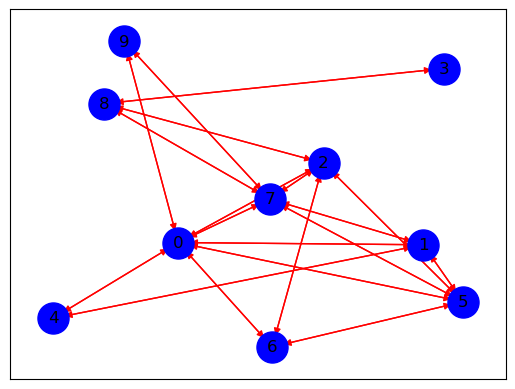

In [8]:
G_preprocessing = nx.DiGraph()
for i in range(len(cossim_prep)):
    G_preprocessing.add_node(i)

for i in range(len(cossim_prep)):
    for j in range(len(cossim_prep)):
        similarity_preprocessing = cossim_prep[i][j]
        if similarity_preprocessing > 0.1 and i != j:
            G_preprocessing.add_edge(i, j)

pos = nx.spring_layout(G_preprocessing, k=2)
nx.draw_networkx_nodes(G_preprocessing, pos, node_size=500, node_color='b')
nx.draw_networkx_edges(G_preprocessing, pos, edge_color='red', arrows=True)
nx.draw_networkx_labels(G_preprocessing, pos)

plt.show()

## Bag Of word

Bag of Words (BoW) merupakan salah satu metode paling sederhana dalam mengubah data teks menjadi vektor yang dapat dipahami oleh komputer. Metode ini sejatinya hanya menghitung frekuensi kemunculan kata pada seluruh dokumen.

In [9]:
kalimat = nltk.sent_tokenize(df['isi_baru'][20])
kalimat = [sentence.replace('.','') for sentence in kalimat]
kata = nltk.word_tokenize(df['isi_baru'][20])
kata = list(set(key for key in kata if key != '.'))

### Occurrence matrix

In [10]:
def vektor_kata(data, kata):
    # Membuat DataFrame untuk menyimpan frekuensi kata
    vektor_kata = pd.DataFrame(0, index=range(len(data)), columns=kata)
    
    for i, sent in enumerate(data):
        # Tokenisasi kalimat menjadi kata-kata
        kata_kalimat = word_tokenize(sent)
        
        # Hitung frekuensi kata menggunakan Counter
        freq_kata = Counter(kata_kalimat)
        
        # Update DataFrame dengan frekuensi kata yang ditemukan dalam kata
        for word, count in freq_kata.items():
            if word in kata:
                vektor_kata.at[i, word] = count

    return vektor_kata

# Pastikan untuk memberikan daftar kata yang benar
vektorisasi_kata = vektor_kata(kalimat, kata)  # Memasukkan 'kata' ke fungsi
print("Vektorisasi Kata:")
vektorisasi_kata

Vektorisasi Kata:


,listyo,asta,november,dirancang,sarjana,palawija,langkah,siang,cita,.sandi,...,kick,membantu,sandi,polisi,swasembada,irjen,berkolaborasi,tindak,polisipolisi,bakomsus
0,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,0,...,0,0,2,0,0,1,0,1,0,1
3,0,1,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Co-occurrence Matrix

Co-occurrence Matrix adalah representasi dari berapa kali pasangan kata tertentu muncul bersama dalam suatu konteks, seperti dalam kalimat, paragraf, atau dokumen. 

In [11]:
def cooc_matrix(data):
    vektor_kata = pd.DataFrame(0, index=kata, columns=kata)
    
    for sent in data:
        kata_kalimat = word_tokenize(sent)
        
        for word1, word2 in combinations(kata_kalimat, 2):#mencari kata yg sering muncul menggunakan combination
            if word1 in kata and word2 in kata:
                # Tambahkan ke matrix untuk kedua arah (word1, word2) dan (word2, word1)
                vektor_kata.at[word1, word2] += 1
                vektor_kata.at[word2, word1] += 1

    return vektor_kata

# Contoh pemanggilan fungsi
cooccurrence_matrix = cooc_matrix(kalimat)
cooccurrence_matrix

,listyo,asta,november,dirancang,sarjana,palawija,langkah,siang,cita,.sandi,...,kick,membantu,sandi,polisi,swasembada,irjen,berkolaborasi,tindak,polisipolisi,bakomsus
listyo,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,1,0,0,0,0,0
asta,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
november,0,1,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
dirancang,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,1,0,1,0,1
sarjana,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
irjen,0,0,0,1,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1,0,1
berkolaborasi,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
tindak,0,0,0,1,0,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,1
polisipolisi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### Consine Similarity

Cosine Similarity adalah ukuran kesamaan antara dua vektor non-zero dalam ruang dimensi yang biasanya digunakan untuk menghitung kemiripan antara dua dokumen teks dalam pemrosesan bahasa alami (NLP). Nilai cosine similarity berkisar dari -1 hingga 1, di mana:

1 berarti vektor (dokumen) sangat mirip (arahnya sama),
0 berarti tidak ada hubungan sama sekali (vektor saling tegak lurus),
-1 berarti vektor berlawanan arah (sangat tidak mirip).
Cosine similarity diukur berdasarkan sudut antara dua vektor, bukan magnitudo (panjang) mereka. Vektor direpresentasikan berdasarkan frekuensi kata (bag of words atau TF-IDF). Semakin kecil sudut antara dua vektor, semakin mirip keduanya.

$$
\text{Cosine Similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}
$$
Di mana:
- **A . B** adalah hasil perkalian dot product antara vektor A dan vektor B.
- **||A||** adalah norm (panjang) dari vektor A.
- **||B||** adalah norm (panjang) dari vektor B.

In [12]:
cosine = cosine_similarity(cooccurrence_matrix)
cosine

array([[1.        , 0.15512631, 0.15512631, ..., 0.07397267, 0.        ,
        0.13076645],
       [0.15512631, 1.        , 0.95454545, ..., 0.19507683, 0.        ,
        0.22990024],
       [0.15512631, 0.95454545, 1.        , ..., 0.19507683, 0.        ,
        0.22990024],
       ...,
       [0.07397267, 0.19507683, 0.19507683, ..., 1.        , 0.        ,
        0.80577284],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.13076645, 0.22990024, 0.22990024, ..., 0.80577284, 0.        ,
        1.        ]])

### Visualisasi Graph

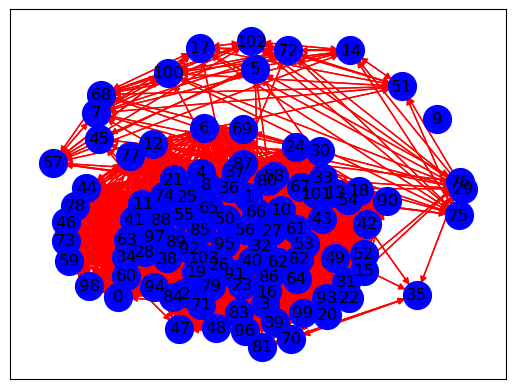

In [13]:
G = nx.DiGraph()
for i in range(len(cosine)):
    G.add_node(i)

for i in range(len(cosine)):
    for j in range(len(cosine)):
        similarity = cosine[i][j]
        if similarity > 0.1 and i != j:
            G.add_edge(i, j)

pos = nx.spring_layout(G, k=2)
nx.draw_networkx_nodes(G, pos, node_size=400, node_color='blue')
nx.draw_networkx_edges(G, pos, edge_color='red', arrows=True)
nx.draw_networkx_labels(G, pos)

plt.show()

### Peringkat Node

In [15]:
rank_word = nx.pagerank(G)

sorted_pagerank= sorted(rank_word.items(), key=lambda x: x[1], reverse=True)
print("Ranked page berita :")
for node, pagerank in sorted_pagerank:
    print(f"Node {node}: {pagerank:.4f}")

Ranked page berita :
Node 36: 0.0154
Node 4: 0.0112
Node 23: 0.0112
Node 25: 0.0112
Node 26: 0.0112
Node 27: 0.0112
Node 32: 0.0112
Node 40: 0.0112
Node 50: 0.0112
Node 53: 0.0112
Node 56: 0.0112
Node 58: 0.0112
Node 61: 0.0112
Node 65: 0.0112
Node 66: 0.0112
Node 71: 0.0112
Node 74: 0.0112
Node 79: 0.0112
Node 82: 0.0112
Node 85: 0.0112
Node 86: 0.0112
Node 88: 0.0112
Node 92: 0.0112
Node 97: 0.0112
Node 103: 0.0112
Node 41: 0.0107
Node 43: 0.0107
Node 62: 0.0107
Node 64: 0.0107
Node 87: 0.0107
Node 91: 0.0107
Node 94: 0.0107
Node 95: 0.0107
Node 1: 0.0107
Node 2: 0.0107
Node 8: 0.0107
Node 10: 0.0107
Node 11: 0.0107
Node 16: 0.0107
Node 21: 0.0107
Node 28: 0.0107
Node 38: 0.0107
Node 5: 0.0097
Node 35: 0.0097
Node 45: 0.0097
Node 70: 0.0097
Node 76: 0.0097
Node 81: 0.0097
Node 3: 0.0095
Node 13: 0.0095
Node 15: 0.0095
Node 18: 0.0095
Node 19: 0.0095
Node 20: 0.0095
Node 22: 0.0095
Node 31: 0.0095
Node 33: 0.0095
Node 37: 0.0095
Node 39: 0.0095
Node 42: 0.0095
Node 48: 0.0095
Node 52:

### hasil kata kunci

In [16]:
print("4 rank node teratas dari berita :")
sentence = ""
for node, pagerank in sorted_pagerank[:4]:
  top_sentence = kata[node]
  sentence += top_sentence + ", "
  print(f"Node {node}: Page Rank = {pagerank:.4f}")
  print(f"kata: {top_sentence}")

4 rank node teratas dari berita :
Node 36: Page Rank = 0.0154
kata: gizi
Node 4: Page Rank = 0.0112
kata: sarjana
Node 23: Page Rank = 0.0112
kata: baca
Node 25: Page Rank = 0.0112
kata: polri


# Hasil Aplikasi Web

link aplikasi : <br>
https://huggingface.co/spaces/Ainachmad/Klasifikasi_Berita_PPW